# 1. Overview and Merging the Data

In [215]:
import pandas as pd 


In [216]:
xl = pd.read_excel('../data/Customer_Churn_Data_Large.xlsx', sheet_name=None)


In [217]:
print(list(xl.keys()))

['Customer_Demographics', 'Transaction_History', 'Customer_Service', 'Online_Activity', 'Churn_Status']


In [218]:
demographics = xl['Customer_Demographics']
transactions = xl['Transaction_History']
service = xl['Customer_Service']
online = xl['Online_Activity']
churn = xl['Churn_Status']

In [219]:
def overview(df):
    print("Shape of Dataset:", df.shape)
    print("\nData Type\n", df.dtypes)
    print("\nFirst five rows\n", df.head())
    print("\nNumber of missing values\n", df.isnull().sum())
    print("\n Number of unique values\n ",df.nunique())

In [220]:
overview(demographics)

Shape of Dataset: (1000, 5)

Data Type
 CustomerID        int64
Age               int64
Gender           object
MaritalStatus    object
IncomeLevel      object
dtype: object

First five rows
    CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium

Number of missing values
 CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64

 Number of unique values
  CustomerID       1000
Age                52
Gender              2
MaritalStatus       4
IncomeLevel         3
dtype: int64


In [221]:
overview(transactions)

Shape of Dataset: (5054, 5)

Data Type
 CustomerID                  int64
TransactionID               int64
TransactionDate    datetime64[ns]
AmountSpent               float64
ProductCategory            object
dtype: object

First five rows
    CustomerID  TransactionID TransactionDate  AmountSpent ProductCategory
0           1           7194      2022-03-27       416.50     Electronics
1           2           7250      2022-08-08        54.96        Clothing
2           2           9660      2022-07-25       197.50     Electronics
3           2           2998      2022-01-25       101.31       Furniture
4           2           1228      2022-07-24       397.37        Clothing

Number of missing values
 CustomerID         0
TransactionID      0
TransactionDate    0
AmountSpent        0
ProductCategory    0
dtype: int64

 Number of unique values
  CustomerID         1000
TransactionID      3864
TransactionDate     365
AmountSpent        4797
ProductCategory       5
dtype: int64


In [222]:
overview(service)

Shape of Dataset: (1002, 5)

Data Type
 CustomerID                   int64
InteractionID                int64
InteractionDate     datetime64[ns]
InteractionType             object
ResolutionStatus            object
dtype: object

First five rows
    CustomerID  InteractionID InteractionDate InteractionType ResolutionStatus
0           1           6363      2022-03-31         Inquiry         Resolved
1           2           3329      2022-03-17         Inquiry         Resolved
2           3           9976      2022-08-24         Inquiry         Resolved
3           4           7354      2022-11-18         Inquiry         Resolved
4           4           5393      2022-07-03         Inquiry       Unresolved

Number of missing values
 CustomerID          0
InteractionID       0
InteractionDate     0
InteractionType     0
ResolutionStatus    0
dtype: int64

 Number of unique values
  CustomerID          668
InteractionID       960
InteractionDate     344
InteractionType       3
ResolutionS

In [223]:
overview(online)

Shape of Dataset: (1000, 4)

Data Type
 CustomerID                 int64
LastLoginDate     datetime64[ns]
LoginFrequency             int64
ServiceUsage              object
dtype: object

First five rows
    CustomerID LastLoginDate  LoginFrequency ServiceUsage
0           1    2023-10-21              34   Mobile App
1           2    2023-12-05               5      Website
2           3    2023-11-15               3      Website
3           4    2023-08-25               2      Website
4           5    2023-10-27              41      Website

Number of missing values
 CustomerID        0
LastLoginDate     0
LoginFrequency    0
ServiceUsage      0
dtype: int64

 Number of unique values
  CustomerID        1000
LastLoginDate      340
LoginFrequency      49
ServiceUsage         3
dtype: int64


In [224]:
overview(churn)

Shape of Dataset: (1000, 2)

Data Type
 CustomerID     int64
ChurnStatus    int64
dtype: object

First five rows
    CustomerID  ChurnStatus
0           1            0
1           2            1
2           3            0
3           4            0
4           5            0

Number of missing values
 CustomerID     0
ChurnStatus    0
dtype: int64

 Number of unique values
  CustomerID     1000
ChurnStatus       2
dtype: int64


### We have average of 5 transactions per customer, we must aggregate before merging

In [225]:
# example transaction
transactions.loc[transactions['CustomerID'] == 2]

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing
5,2,8903,2022-01-09,285.21,Electronics
6,2,3527,2022-09-16,311.34,Electronics
7,2,9279,2022-11-19,199.73,Groceries


In [226]:
# Aggregate Transaction_History (5054 to 1000 rows)
transactions['TransactionDate'] = pd.to_datetime(transactions['TransactionDate'])
ref = transactions['TransactionDate'].max()  

transactions_aggregated = transactions.groupby('CustomerID').agg(
        TotalSpend = ('AmountSpent', 'sum'),
        AvgSpend = ('AmountSpent', 'mean'),
        NumTransactions = ('TransactionID', 'count'),
        FavCategory = ('ProductCategory', lambda x: x.mode()[0]),
        DaysSinceLastTx = ('TransactionDate', lambda x: (ref-x.max()).days)
        
    ).reset_index()

transactions_aggregated


,CustomerID,TotalSpend,AvgSpend,NumTransactions,FavCategory,DaysSinceLastTx
0,1,416.50,416.500000,1,Electronics,279
1,2,1547.42,221.060000,7,Electronics,42
2,3,1702.98,283.830000,6,Furniture,84
3,4,917.29,183.458000,5,Electronics,4
4,5,2001.49,250.186250,8,Electronics,10
...,...,...,...,...,...,...
995,996,227.25,227.250000,1,Books,160
996,997,419.82,209.910000,2,Electronics,67
997,998,252.15,252.150000,1,Books,104
998,999,2393.26,265.917778,9,Furniture,24


### Check for missing customer service records

In [227]:
all_customers     = set(demographics['CustomerID'])
service_customers = set(service['CustomerID'])

missing = all_customers - service_customers
print(len(missing))         
print(sorted(missing)[:10])

332
[5, 7, 10, 21, 32, 39, 42, 46, 47, 48]


In [228]:
service.columns

Index(['CustomerID', 'InteractionID', 'InteractionDate', 'InteractionType',
       'ResolutionStatus'],
      dtype='object')

In [229]:
service['InteractionType'].unique(), service['ResolutionStatus'].unique()

(array(['Inquiry', 'Feedback', 'Complaint'], dtype=object),
 array(['Resolved', 'Unresolved'], dtype=object))

In [230]:
# We are missing 332 service records we must aggregate it
service_aggregated = service.groupby('CustomerID').agg(
    NumInteractions = ('InteractionID', 'count'),
    NumComplaints = ('InteractionType', lambda x: (x=='Complaint').sum()),
    NumUnresolved = ('ResolutionStatus', lambda x: (x=='Unresolved').sum())
).reset_index()
service_aggregated

,CustomerID,NumInteractions,NumComplaints,NumUnresolved
0,1,1,0,0
1,2,1,0,0
2,3,1,0,0
3,4,2,0,1
4,6,1,0,0
...,...,...,...,...
663,989,2,2,2
664,990,2,1,1
665,992,1,0,1
666,994,2,2,2


### Now we can combine all sheets

In [231]:
# Engineer online activity features
online['LastLoginDate'] = pd.to_datetime(online['LastLoginDate'])
ref_login = pd.Timestamp('2024-01-01')
online['DaysSinceLastLogin'] = (ref_login - online['LastLoginDate']).dt.days

In [232]:
# left join

df = demographics.merge(transactions_aggregated, on='CustomerID', how='left') \
    .merge(service_aggregated, on='CustomerID', how='left') \
        .merge(online[['CustomerID','DaysSinceLastLogin', 'LoginFrequency', 'LastLoginDate', 'ServiceUsage']], on='CustomerID', how='left') \
            .merge(churn, on='CustomerID', how='left')
            
# add age group
df['AgeGroup'] = pd.cut(df['Age'], bins = [17,35,55,70], labels=['Young', 'Middle', 'Senior'])

In [233]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpend,AvgSpend,NumTransactions,FavCategory,DaysSinceLastTx,NumInteractions,NumComplaints,NumUnresolved,DaysSinceLastLogin,LoginFrequency,LastLoginDate,ServiceUsage,ChurnStatus,AgeGroup
0,1,62,M,Single,Low,416.50,416.50000,1,Electronics,279,1.0,0.0,0.0,72,34,2023-10-21,Mobile App,0,Senior
1,2,65,M,Married,Low,1547.42,221.06000,7,Electronics,42,1.0,0.0,0.0,27,5,2023-12-05,Website,1,Senior
2,3,18,M,Single,Low,1702.98,283.83000,6,Furniture,84,1.0,0.0,0.0,47,3,2023-11-15,Website,0,Young
3,4,21,M,Widowed,Low,917.29,183.45800,5,Electronics,4,2.0,0.0,1.0,129,2,2023-08-25,Website,0,Young
4,5,21,M,Divorced,Medium,2001.49,250.18625,8,Electronics,10,NaN,NaN,NaN,66,41,2023-10-27,Website,0,Young


In [234]:
print(df.shape)
print(df.isnull().any())

(1000, 19)
CustomerID            False
Age                   False
Gender                False
MaritalStatus         False
IncomeLevel           False
TotalSpend            False
AvgSpend              False
NumTransactions       False
FavCategory           False
DaysSinceLastTx       False
NumInteractions        True
NumComplaints          True
NumUnresolved          True
DaysSinceLastLogin    False
LoginFrequency        False
LastLoginDate         False
ServiceUsage          False
ChurnStatus           False
AgeGroup              False
dtype: bool


# 2. Statistics

In [235]:
df.describe()

,CustomerID,Age,TotalSpend,AvgSpend,NumTransactions,DaysSinceLastTx,NumInteractions,NumComplaints,NumUnresolved,DaysSinceLastLogin,LoginFrequency,LastLoginDate,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,668.000000,668.000000,668.000000,1000.000000,1000.000000,1000,1000.000000
mean,500.500000,43.267000,1267.074950,248.806511,5.054000,78.051000,1.500000,0.501497,0.717066,179.105000,25.912000,2023-07-05 21:28:48,0.204000
min,1.000000,18.000000,9.800000,9.800000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,2023-01-01 00:00:00,0.000000
25%,250.750000,30.000000,626.685000,203.734167,3.000000,20.000000,1.000000,0.000000,0.000000,91.750000,13.750000,2023-04-08 00:00:00,0.000000
50%,500.500000,43.000000,1232.880000,250.121458,5.000000,52.000000,1.500000,0.000000,1.000000,174.500000,27.000000,2023-07-10 12:00:00,0.000000
75%,750.250000,56.000000,1791.902500,295.023854,7.000000,106.000000,2.000000,1.000000,1.000000,268.000000,38.000000,2023-10-01 06:00:00,0.000000
max,1000.000000,69.000000,3386.040000,496.990000,9.000000,355.000000,2.000000,2.000000,2.000000,365.000000,49.000000,2023-12-31 00:00:00,1.000000
std,288.819436,15.242311,738.590013,79.372766,2.603433,78.720654,0.500375,0.603586,0.638032,104.897299,14.055953,NaN,0.403171


In [236]:
df.describe(include='object')

,Gender,MaritalStatus,IncomeLevel,FavCategory,ServiceUsage
count,1000,1000,1000,1000,1000
unique,2,4,3,5,3
top,F,Widowed,High,Books,Online Banking
freq,513,276,349,313,349


In [237]:
# Categorical value counts
for col in ['Gender','MaritalStatus','IncomeLevel','ServiceUsage','FavCategory']:
    print(col, df[col].value_counts().to_dict())

Gender {'F': 513, 'M': 487}
MaritalStatus {'Widowed': 276, 'Married': 261, 'Divorced': 248, 'Single': 215}
IncomeLevel {'High': 349, 'Medium': 326, 'Low': 325}
ServiceUsage {'Online Banking': 349, 'Mobile App': 342, 'Website': 309}
FavCategory {'Books': 313, 'Clothing': 226, 'Electronics': 182, 'Furniture': 141, 'Groceries': 138}


# 3. Visualizations

In [238]:
import matplotlib.pyplot as plt 
import seaborn as sns 

C:\Users\rohan\AppData\Local\Temp\ipykernel_5180\562396566.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('AgeGroup')['ChurnStatus'].mean().plot(kind='bar', ax=axes[1,0], color='#E24B4A')


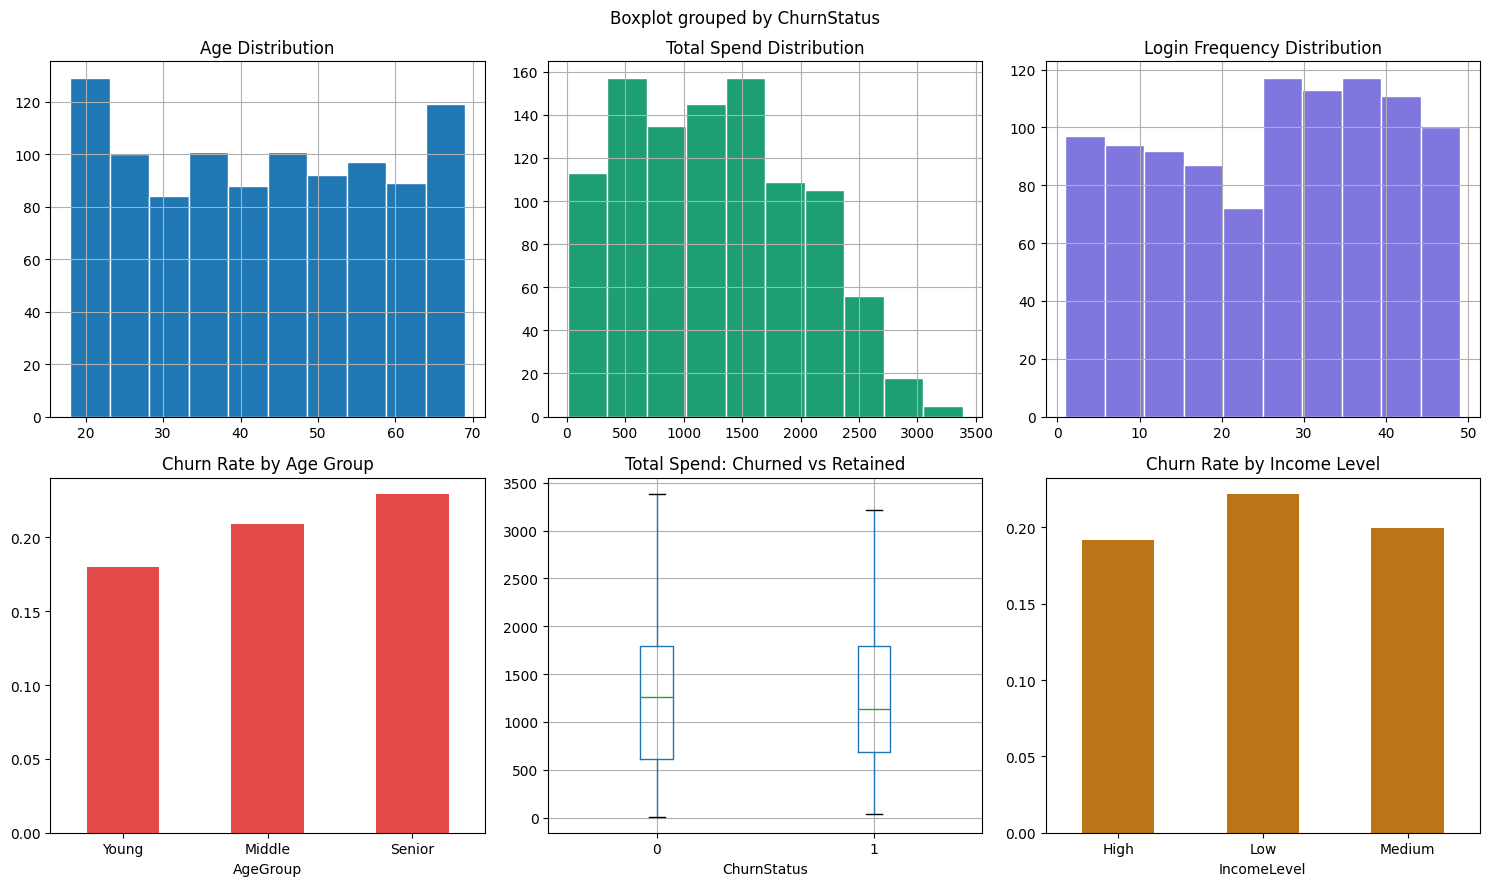

In [239]:
fig, axes = plt.subplots(2,3,figsize=(15,9))

# Histogram - age
df['Age'].hist( ax=axes[0,0], edgecolor='white')
axes[0,0].set_title('Age Distribution')

# Histogram - total spending
df['TotalSpend'].hist( ax=axes[0,1], color='#1D9E75',edgecolor='white')
axes[0,1].set_title('Total Spend Distribution')

# Histogram - login frequency
df['LoginFrequency'].hist(ax=axes[0,2],color='#7F77DD', edgecolor='white')
axes[0,2].set_title('Login Frequency Distribution')


# Bar - Churn rate by AgeGroup
df.groupby('AgeGroup')['ChurnStatus'].mean().plot(kind='bar', ax=axes[1,0], color='#E24B4A')
axes[1,0].set_title('Churn Rate by Age Group')
axes[1,0].set_xticklabels(axes[1,0].get_xticklabels(), rotation=0)



# Box plot - Total spending by churn status
df.boxplot(column='TotalSpend', by='ChurnStatus', ax=axes[1,1])
axes[1,1].set_title('Total Spend: Churned vs Retained')

# Bar - Churn rate by Income Level
df.groupby('IncomeLevel')['ChurnStatus'].mean().plot(kind='bar', ax=axes[1,2], color='#BA7517')
axes[1,2].set_title('Churn Rate by Income Level')
axes[1,2].set_xticklabels(axes[1,2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()




# 4. Correlation

In [240]:
df.corrwith(df['ChurnStatus'], numeric_only=True)

CustomerID           -0.011528
Age                   0.029407
TotalSpend            0.001324
AvgSpend              0.044811
NumTransactions      -0.008598
DaysSinceLastTx       0.003362
NumInteractions      -0.062044
NumComplaints         0.001730
NumUnresolved        -0.020267
DaysSinceLastLogin    0.009055
LoginFrequency       -0.081615
ChurnStatus           1.000000
dtype: float64

In [241]:
churned = df[df['ChurnStatus']==1]['LoginFrequency'].mean()
retained = df[df['ChurnStatus']==0]['LoginFrequency'].mean()
print(f"Avg logins - churned: {churned:.1f}, retained: {retained:.1f}")

Avg logins - churned: 23.6, retained: 26.5


### All correlations are weak (|r| < 0.1).

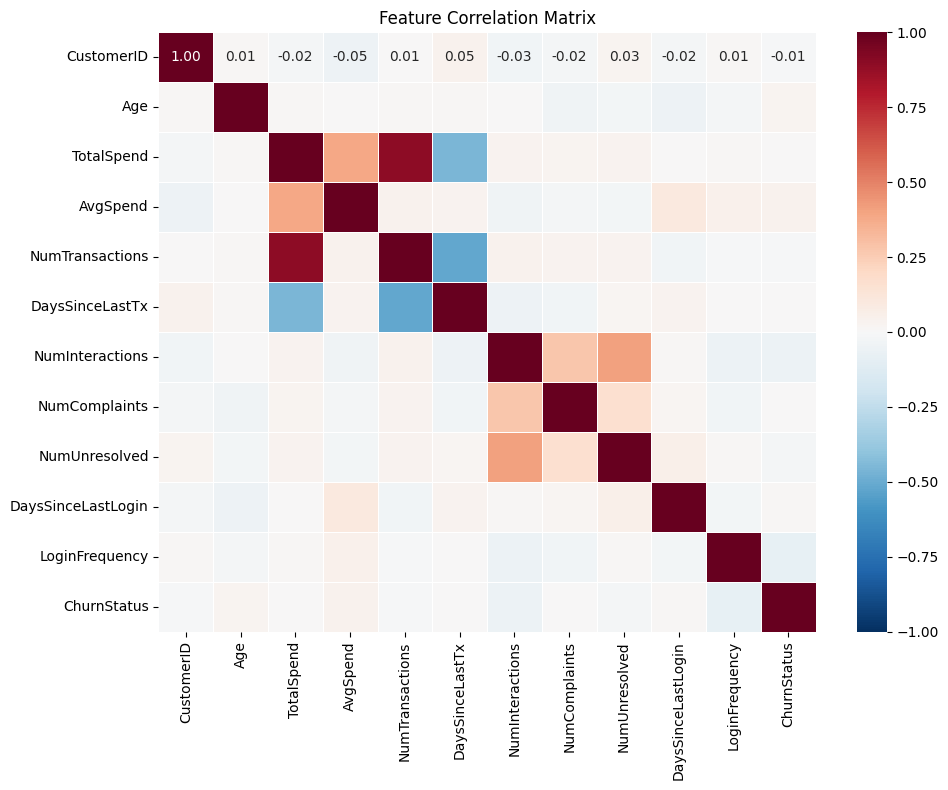

In [242]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


# 5. Data Cleaning

### Outliers

In [243]:
# Outliers
numeric_cols = ['Age', 'TotalSpend', 'AvgSpend', 'NumTransactions',
                'LoginFrequency']

for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    low_outliers  = df[df[col] < lower]
    high_outliers = df[df[col] > upper]
    total         = len(low_outliers) + len(high_outliers)

    status = "✓" if total == 0 else "!"

    print(f"{status} {col}")
    print(f"   Range: {df[col].min():.1f} – {df[col].max():.1f}")
    print(f"   IQR:   Q1={Q1:.1f}, Q3={Q3:.1f}")
    print(f"   Outliers: {len(low_outliers)} low, {len(high_outliers)} high")
    print()

✓ Age
   Range: 18.0 – 69.0
   IQR:   Q1=30.0, Q3=56.0
   Outliers: 0 low, 0 high

✓ TotalSpend
   Range: 9.8 – 3386.0
   IQR:   Q1=626.7, Q3=1791.9
   Outliers: 0 low, 0 high

! AvgSpend
   Range: 9.8 – 497.0
   IQR:   Q1=203.7, Q3=295.0
   Outliers: 23 low, 15 high

✓ NumTransactions
   Range: 1.0 – 9.0
   IQR:   Q1=3.0, Q3=7.0
   Outliers: 0 low, 0 high

✓ LoginFrequency
   Range: 1.0 – 49.0
   IQR:   Q1=13.8, Q3=38.0
   Outliers: 0 low, 0 high



In [244]:
# Fix AvgSpend
low = df['AvgSpend'].quantile(0.05)
high = df['AvgSpend'].quantile(0.95)

df['AvgSpend_clean'] = df['AvgSpend'].clip(lower=low, upper=high)

print(f"Before: {df['AvgSpend'].min():.1f} – {df['AvgSpend'].max():.1f}")
print(f"After:  {df['AvgSpend_clean'].min():.1f} – {df['AvgSpend_clean'].max():.1f}")


Before: 9.8 – 497.0
After:  111.5 – 379.1


### Fill missing customer service records

In [245]:
# low-engagement customers

df['HasServiceRecord'] = (df['NumInteractions']>0).astype(int)

for col in ['NumInteractions','NumComplaints','NumUnresolved']:
    df[col] = df[col].fillna(0)
    
print("Customers with no service record:", (df['HasServiceRecord']==0).sum())  # 332

Customers with no service record: 332


# 6. Encoding

In [246]:
df_enc = df.copy()
categorical_columns = df_enc.select_dtypes(include='object').columns.to_list()

for col in categorical_columns:
    print(col, df_enc[col].unique())

Gender ['M' 'F']
MaritalStatus ['Single' 'Married' 'Widowed' 'Divorced']
IncomeLevel ['Low' 'Medium' 'High']
FavCategory ['Electronics' 'Furniture' 'Books' 'Clothing' 'Groceries']
ServiceUsage ['Mobile App' 'Website' 'Online Banking']


In [247]:
# 1. Gender - binary label encoding
df_enc['Gender_enc'] = df_enc['Gender'].map({'M':1, 'F':0})

In [248]:
df_enc['Gender_enc']

0      1
1      1
2      1
3      1
4      1
      ..
995    0
996    1
997    1
998    1
999    1
Name: Gender_enc, Length: 1000, dtype: int64

In [249]:
# 2. IncomeLevel - ordinal (Low < Medium < High)
income_map = {'Low':0, 'Medium': 1, 'High':2}
df_enc['Income_enc'] = df_enc['IncomeLevel'].map(income_map)
df_enc['Income_enc']

0      0
1      0
2      0
3      0
4      1
      ..
995    0
996    2
997    0
998    2
999    0
Name: Income_enc, Length: 1000, dtype: int64

In [250]:
# 3. Marital Status - one-hot (4 categories, no natural order)
ms = pd.get_dummies(df_enc['MaritalStatus'], prefix='MS', drop_first=True)
df_enc = pd.concat([df_enc,ms], axis=1)



In [251]:
# 4. ServiceUsage - one-hot
su  = pd.get_dummies(df_enc['ServiceUsage'], prefix='SU', drop_first=True)
df_enc = pd.concat([df_enc, su], axis=1)



In [252]:
# 5. FavCategory - one-hot
fc = pd.get_dummies(df_enc['FavCategory'], prefix='FC', drop_first=True)
df_enc = pd.concat([df_enc,fc], axis=1)

In [253]:
# 6. AgeGroup
df_enc['AgeGroup_enc'] = pd.cut(df['Age'], bins=[17,35,55,70], labels=[0,1,2]).astype(int)

In [254]:
df_enc = df_enc.loc[:, ~df_enc.columns.duplicated()]
print(df_enc.columns)

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel',
       'TotalSpend', 'AvgSpend', 'NumTransactions', 'FavCategory',
       'DaysSinceLastTx', 'NumInteractions', 'NumComplaints', 'NumUnresolved',
       'DaysSinceLastLogin', 'LoginFrequency', 'LastLoginDate', 'ServiceUsage',
       'ChurnStatus', 'AgeGroup', 'AvgSpend_clean', 'HasServiceRecord',
       'Gender_enc', 'Income_enc', 'MS_Married', 'MS_Single', 'MS_Widowed',
       'SU_Online Banking', 'SU_Website', 'FC_Clothing', 'FC_Electronics',
       'FC_Furniture', 'FC_Groceries', 'AgeGroup_enc'],
      dtype='object')


In [255]:
df_enc = df_enc.drop(columns=['CustomerID','Gender','MaritalStatus','IncomeLevel',
             'ServiceUsage','FavCategory','AgeGroup', 'LastLoginDate'])

In [256]:
bool_cols = df_enc.select_dtypes(include='bool').columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

In [257]:
df_enc.dtypes

Age                     int64
TotalSpend            float64
AvgSpend              float64
NumTransactions         int64
DaysSinceLastTx         int64
NumInteractions       float64
NumComplaints         float64
NumUnresolved         float64
DaysSinceLastLogin      int64
LoginFrequency          int64
ChurnStatus             int64
AvgSpend_clean        float64
HasServiceRecord        int32
Gender_enc              int64
Income_enc              int64
MS_Married              int32
MS_Single               int32
MS_Widowed              int32
SU_Online Banking       int32
SU_Website              int32
FC_Clothing             int32
FC_Electronics          int32
FC_Furniture            int32
FC_Groceries            int32
AgeGroup_enc            int32
dtype: object

# 7. Feature Engineering

In [258]:
import numpy as np

df_enc['SpendPerTx'] = df['TotalSpend'] / df['NumTransactions']
df_enc['ComplaintRate'] = (df['NumComplaints'] / df['NumInteractions'].replace(0, np.nan)).fillna(0)

df_enc['IsHighRisk'] = ((df['LoginFrequency']<10) & (df['NumComplaints'] > 0)).astype(int)


In [259]:
# Scale numerics
numeric_cols = df_enc.select_dtypes(include='number').columns.to_list()
numeric_cols.remove('ChurnStatus')

In [260]:
numeric_cols

['Age',
 'TotalSpend',
 'AvgSpend',
 'NumTransactions',
 'DaysSinceLastTx',
 'NumInteractions',
 'NumComplaints',
 'NumUnresolved',
 'DaysSinceLastLogin',
 'LoginFrequency',
 'AvgSpend_clean',
 'HasServiceRecord',
 'Gender_enc',
 'Income_enc',
 'MS_Married',
 'MS_Single',
 'MS_Widowed',
 'SU_Online Banking',
 'SU_Website',
 'FC_Clothing',
 'FC_Electronics',
 'FC_Furniture',
 'FC_Groceries',
 'AgeGroup_enc',
 'SpendPerTx',
 'ComplaintRate',
 'IsHighRisk']

In [261]:
df_enc.dtypes

Age                     int64
TotalSpend            float64
AvgSpend              float64
NumTransactions         int64
DaysSinceLastTx         int64
NumInteractions       float64
NumComplaints         float64
NumUnresolved         float64
DaysSinceLastLogin      int64
LoginFrequency          int64
ChurnStatus             int64
AvgSpend_clean        float64
HasServiceRecord        int32
Gender_enc              int64
Income_enc              int64
MS_Married              int32
MS_Single               int32
MS_Widowed              int32
SU_Online Banking       int32
SU_Website              int32
FC_Clothing             int32
FC_Electronics          int32
FC_Furniture            int32
FC_Groceries            int32
AgeGroup_enc            int32
SpendPerTx            float64
ComplaintRate         float64
IsHighRisk              int32
dtype: object

In [262]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_enc[numeric_cols] = scaler.fit_transform(df_enc[numeric_cols])

In [263]:
df_final = df_enc 
df_final.dtypes

Age                   float64
TotalSpend            float64
AvgSpend              float64
NumTransactions       float64
DaysSinceLastTx       float64
NumInteractions       float64
NumComplaints         float64
NumUnresolved         float64
DaysSinceLastLogin    float64
LoginFrequency        float64
ChurnStatus             int64
AvgSpend_clean        float64
HasServiceRecord      float64
Gender_enc            float64
Income_enc            float64
MS_Married            float64
MS_Single             float64
MS_Widowed            float64
SU_Online Banking     float64
SU_Website            float64
FC_Clothing           float64
FC_Electronics        float64
FC_Furniture          float64
FC_Groceries          float64
AgeGroup_enc          float64
SpendPerTx            float64
ComplaintRate         float64
IsHighRisk            float64
dtype: object

In [264]:
df_final.to_excel('Churn_Model_Ready.xlsx', index=False)
print(f"Exported: {df_final.shape}")

Exported: (1000, 28)
